# Case Study Diabetes - Preprocessing

* Should really rewrite 3 main imputation methods used and descriptive statistics/other comparison methods into defined functions for repeated calling throughout the notebook - lots of repeated cells
* Would be useful for future reference as well, just copy old general purpose imputation functions across

## Import libraries

In [186]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

## Read in data

In [188]:
data_path = Path("visceral-adipose-tissue-measurements-during-pregnancy-1.0.0/visceral_fat.csv")

if not data_path.exists():
    raise FileNotFoundError("file not found")

diabetes = pd.read_csv(data_path)
diabetes.head()

,number,age (years),ethnicity,diabetes mellitus,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),current gestational age,pregnancies (number),first fasting glucose (mg/dl),bmi pregestational (kg/m),gestational age at birth,type of delivery,child birth weight (g),gestational dm
0,1,20,NaN,0,73.5,125.0,28.1,"12,1",1.0,NaN,33.20,"41,0",1,3840,0
1,2,28,0.0,0,75.5,112.0,43.1,"11,5",1.0,76.0,21.50,"39,1",0,2810,0
2,5,21,1.0,0,70.5,116.0,41.4,"12,6",1.0,86.0,21.41,"39,5",0,2455,0
3,9,25,0.0,0,92.5,167.0,39.6,"16,2",4.0,NaN,55.36,"39,4",0,3400,0
4,13,33,1.0,0,79.0,137.0,67.8,"11,2",2.0,86.0,30.85,"40,2",1,3930,1


## EDA - Initial data assessment (Task 1)

In [190]:
# Basic data overview to spot obvious data issues or places for further assessment
display(diabetes.info(),diabetes.head(),diabetes.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   number                         133 non-null    int64  
 1   age (years)                    133 non-null    int64  
 2   ethnicity                      132 non-null    float64
 3   diabetes mellitus              133 non-null    int64  
 4   mean diastolic bp (mmhg)       133 non-null    float64
 5   mean systolic bp (mmhg)        133 non-null    float64
 6   central armellini fat (mm)     133 non-null    float64
 7   current gestational age        133 non-null    object 
 8   pregnancies (number)           128 non-null    float64
 9   first fasting glucose (mg/dl)  103 non-null    float64
 10  bmi pregestational (kg/m)      132 non-null    float64
 11  gestational age at birth       133 non-null    object 
 12  type of delivery               133 non-null    int

None

,number,age (years),ethnicity,diabetes mellitus,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),current gestational age,pregnancies (number),first fasting glucose (mg/dl),bmi pregestational (kg/m),gestational age at birth,type of delivery,child birth weight (g),gestational dm
0,1,20,NaN,0,73.5,125.0,28.1,"12,1",1.0,NaN,33.20,"41,0",1,3840,0
1,2,28,0.0,0,75.5,112.0,43.1,"11,5",1.0,76.0,21.50,"39,1",0,2810,0
2,5,21,1.0,0,70.5,116.0,41.4,"12,6",1.0,86.0,21.41,"39,5",0,2455,0
3,9,25,0.0,0,92.5,167.0,39.6,"16,2",4.0,NaN,55.36,"39,4",0,3400,0
4,13,33,1.0,0,79.0,137.0,67.8,"11,2",2.0,86.0,30.85,"40,2",1,3930,1


,number,age (years),ethnicity,diabetes mellitus,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),pregnancies (number),first fasting glucose (mg/dl),bmi pregestational (kg/m),type of delivery,child birth weight (g),gestational dm
count,133.000000,133.000000,132.000000,133.000000,133.000000,133.000000,133.000000,128.000000,103.000000,132.000000,133.000000,133.000000,133.000000
mean,161.248120,25.804511,0.439394,0.007519,70.593985,116.578947,44.230827,2.351562,81.272816,27.871136,0.240602,3257.563910,0.135338
std,82.703505,6.366887,0.498204,0.086711,8.657662,13.879602,14.606195,1.686397,9.429794,6.874268,0.429065,490.318578,0.343378
min,1.000000,15.000000,0.000000,0.000000,51.500000,90.000000,12.700000,1.000000,60.000000,15.810000,0.000000,1105.000000,0.000000
25%,78.000000,21.000000,0.000000,0.000000,64.500000,107.000000,34.600000,1.000000,76.500000,22.550000,0.000000,2944.000000,0.000000
50%,187.000000,25.000000,0.000000,0.000000,70.000000,114.000000,42.500000,2.000000,80.000000,26.260000,0.000000,3220.000000,0.000000
75%,228.000000,30.000000,1.000000,0.000000,75.500000,125.000000,52.700000,3.000000,86.500000,30.935000,0.000000,3610.000000,0.000000
max,287.000000,43.000000,1.000000,1.000000,100.500000,167.000000,94.400000,9.000000,114.000000,55.360000,1.000000,4534.000000,1.000000


**Notes from first step**
* Null data in several columns - requires attention
* .describe() output doesn't seem to have obvious issues except potential diabetes case that should've been excluded?

In [192]:
# Value counts for non-continuous columns to look for errors
print("Ethnicity", diabetes["ethnicity"].value_counts())
print("Diabetes", diabetes["diabetes mellitus"].value_counts())
print("Pregnancies", diabetes["pregnancies (number)"].value_counts())
print("Type of delivery", diabetes["type of delivery"].value_counts())
print("Gestational dm", diabetes["gestational dm"].value_counts())

Ethnicity ethnicity
0.0    74
1.0    58
Name: count, dtype: int64
Diabetes diabetes mellitus
0    132
1      1
Name: count, dtype: int64
Pregnancies pregnancies (number)
1.0    51
2.0    33
3.0    21
4.0    10
5.0     7
9.0     2
8.0     2
6.0     2
Name: count, dtype: int64
Type of delivery type of delivery
0    101
1     32
Name: count, dtype: int64
Gestational dm gestational dm
0    115
1     18
Name: count, dtype: int64


* Value counts look good apart from 1 previous diabetes case

In [194]:
# Sum of NAs for columns with missing data
for i in diabetes.columns:
    if diabetes[i].isnull().any():
        print(i, diabetes[i].isnull().sum())

ethnicity 1
pregnancies (number) 5
first fasting glucose (mg/dl) 30
bmi pregestational (kg/m) 1


* Displaying exact missing data for correction in following section

## Data cleaning - strategies for handling missing data (Task 2)

In [197]:
# Before any other data cleaning, remove the diabetes case that should've been excluded from the database by the exclusion criteria
diabetes_clean = diabetes[diabetes["diabetes mellitus"] == 0].copy()
print("Diabetes", diabetes_clean["diabetes mellitus"].value_counts())

Diabetes diabetes mellitus
0    132
Name: count, dtype: int64


**Looking at feature: ethnicity**

<Axes: xlabel='ethnicity', ylabel='Count'>

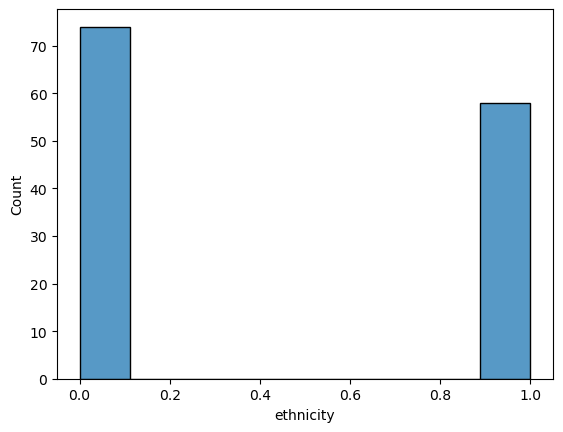

In [199]:
# Data distribution
sns.histplot(diabetes["ethnicity"])

* Binary categorical data
* 1 missing value
* Solution: assign missing value to modal class (0 - White)

In [201]:
diabetes_clean["ethnicity"] = diabetes_clean["ethnicity"].fillna(0)
print("Missing ethnicity data", diabetes_clean["ethnicity"].isnull().sum())

Missing ethnicity data 0


**Looking at feature: pregnancies (number)**

<Axes: xlabel='pregnancies (number)', ylabel='Count'>

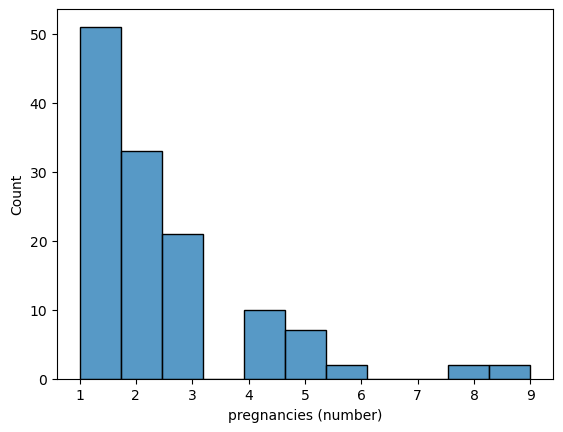

In [203]:
sns.histplot(diabetes["pregnancies (number)"])

* Discrete numerical data
* 5 missing entries

* Possible solutions:
  * Assign to median value
    * Reduces variance by injecting 5 values into centre of data
  * Assign to modal value
    * Over represents the dominant class
  * Assign to rounded mean value
    * Median/mode more suited to discrete data
  * Stochastic imputation using distribution of pregnancies (number) as probabilities for assignment
    * Introduces random noise, dataset too small to absorb stochastic variation safely without potential damage to structural relationships
  * Deterministic ratio imputation using distribution of pregnancies (number) as ratio for assignment
    * Blindly satisfies global ratio without looking at patient, again may cause potential damage to structural relationships
  * KNN imputation
    * More complex imputation, can't handle missing data in other columns so would have to use iterative imputation or clean other columns first

In [205]:
# Median
diabetes_preg_median = diabetes_clean.copy()
diabetes_preg_median["pregnancies (number)"] = diabetes_preg_median["pregnancies (number)"].fillna(
    diabetes_preg_median["pregnancies (number)"].median()
)
print("Missing pregnancy data", diabetes_preg_median["pregnancies (number)"].isnull().sum())

# Mode
diabetes_preg_mode = diabetes_clean.copy()
diabetes_preg_mode["pregnancies (number)"] = diabetes_preg_mode["pregnancies (number)"].fillna(
    diabetes_preg_mode["pregnancies (number)"].mode()[0]
)
print("Missing pregnancy data", diabetes_preg_mode["pregnancies (number)"].isnull().sum())

Missing pregnancy data 0
Missing pregnancy data 0


In [206]:
# Deterministic ratio imputation logic and logging/debug
diabetes_preg_detrat = diabetes_clean.copy()

ratios = diabetes_preg_detrat["pregnancies (number)"].value_counts(normalize = True)
missing_index = diabetes_preg_detrat[diabetes_preg_detrat["pregnancies (number)"].isnull()].index
num_missing = len(missing_index)
print("Missing n =", num_missing)
display(ratios, missing_index)

allocations = (ratios * num_missing)
allocations_rounded = (ratios * num_missing).round()
allocations_remainder = allocations - allocations_rounded
display(allocations, allocations_rounded, allocations_remainder)

while allocations_rounded.sum() < num_missing:
    target_idx = allocations_remainder.idxmax()
    allocations_rounded[allocations_remainder.idxmax()] += 1
    allocations_remainder[allocations_remainder.idxmax()] -= 1

while allocations_rounded.sum() > num_missing:
    target_idx = allocations_remainder.idxmin()
    allocations_rounded[allocations_remainder.idxmin()] -= 1
    allocations_remainder[allocations_remainder.idxmin()] += 1

display(allocations, allocations_rounded, allocations_remainder)

Missing n = 5


pregnancies (number)
1.0    0.401575
2.0    0.259843
3.0    0.165354
4.0    0.078740
5.0    0.055118
9.0    0.015748
8.0    0.015748
6.0    0.007874
Name: proportion, dtype: float64

Index([22, 78, 93, 110, 111], dtype='int64')

pregnancies (number)
1.0    2.007874
2.0    1.299213
3.0    0.826772
4.0    0.393701
5.0    0.275591
9.0    0.078740
8.0    0.078740
6.0    0.039370
Name: proportion, dtype: float64

pregnancies (number)
1.0    2.0
2.0    1.0
3.0    1.0
4.0    0.0
5.0    0.0
9.0    0.0
8.0    0.0
6.0    0.0
Name: proportion, dtype: float64

pregnancies (number)
1.0    0.007874
2.0    0.299213
3.0   -0.173228
4.0    0.393701
5.0    0.275591
9.0    0.078740
8.0    0.078740
6.0    0.039370
Name: proportion, dtype: float64

pregnancies (number)
1.0    2.007874
2.0    1.299213
3.0    0.826772
4.0    0.393701
5.0    0.275591
9.0    0.078740
8.0    0.078740
6.0    0.039370
Name: proportion, dtype: float64

pregnancies (number)
1.0    2.0
2.0    1.0
3.0    1.0
4.0    1.0
5.0    0.0
9.0    0.0
8.0    0.0
6.0    0.0
Name: proportion, dtype: float64

pregnancies (number)
1.0    0.007874
2.0    0.299213
3.0   -0.173228
4.0   -0.606299
5.0    0.275591
9.0    0.078740
8.0    0.078740
6.0    0.039370
Name: proportion, dtype: float64

In [207]:
# Performing deterministic ratio imputation using missing entry index and final allocations from previous cell
# this cell will mess up if ran after glucose detrat imputation, rerun cell above if necessary or rerun whole notebook topdown
list(allocations_rounded.items())[1]
preg_detrat_imp_values = []
for i in list(allocations_rounded.items()):
    preg_detrat_imp_values.extend([i[0]] * int(i[1]))
print(preg_detrat_imp_values)
diabetes_preg_detrat.loc[missing_index, "pregnancies (number)"] = preg_detrat_imp_values
display(diabetes_preg_detrat.loc[missing_index],
        ("Missing pregnancy data", diabetes_preg_detrat["pregnancies (number)"].isnull().sum()))

[1.0, 1.0, 2.0, 3.0, 4.0]


,number,age (years),ethnicity,diabetes mellitus,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),current gestational age,pregnancies (number),first fasting glucose (mg/dl),bmi pregestational (kg/m),gestational age at birth,type of delivery,child birth weight (g),gestational dm
22,48,39,0.0,0,70.0,108.5,49.4,"19,4",1.0,87.0,20.80,"39,5",0,2975,0
78,201,30,0.0,0,57.0,98.5,45.3,"17,1",1.0,NaN,19.02,"39,4",0,3220,0
93,220,22,1.0,0,79.5,125.0,41.6,"9,1",2.0,NaN,28.10,"40,2",0,3350,0
110,239,22,1.0,0,51.5,93.5,49.9,"18,1",3.0,NaN,22.18,"39,5",0,2888,0
111,240,25,1.0,0,58.0,101.0,49.3,"18,3",4.0,NaN,30.70,"40,1",0,3528,1


('Missing pregnancy data', 0)

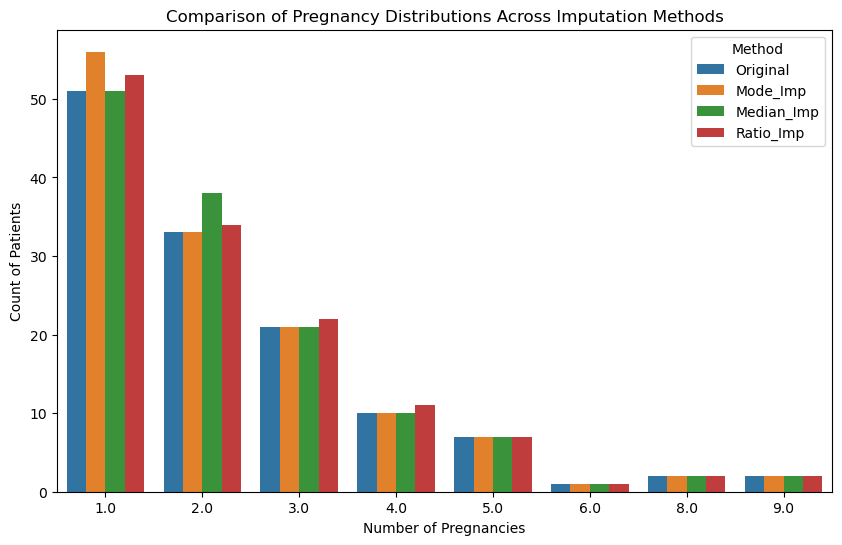

In [208]:
## Comparing data following different imputation methods
# Combine the column from each dataset into a temporary DataFrame for plotting
comparison_df = pd.DataFrame({
    'Original': diabetes_clean['pregnancies (number)'],
    'Mode_Imp': diabetes_preg_mode['pregnancies (number)'],
    'Median_Imp': diabetes_preg_median['pregnancies (number)'],
    'Ratio_Imp': diabetes_preg_detrat['pregnancies (number)']
})

# Melt the dataframe to make it compatible with seaborn
df_melted = comparison_df.melt(var_name='Method', value_name='Pregnancies')

plt.figure(figsize=(10, 6))
sns.countplot(data=df_melted, x='Pregnancies', hue='Method')
plt.title('Comparison of Pregnancy Distributions Across Imputation Methods')
plt.ylabel('Count of Patients')
plt.xlabel('Number of Pregnancies')
plt.show()

In [209]:
# Descriptive statistics comparison
stats_comparison = pd.DataFrame({
    'Original': [diabetes_clean['pregnancies (number)'].mean(), diabetes_clean['pregnancies (number)'].median(), diabetes_clean['pregnancies (number)'].std(), diabetes_clean['pregnancies (number)'].var()],
    'Mode imputation': [diabetes_preg_mode['pregnancies (number)'].mean(), diabetes_preg_mode['pregnancies (number)'].median(), diabetes_preg_mode['pregnancies (number)'].std(), diabetes_preg_mode['pregnancies (number)'].var()],
    'Median imputation': [diabetes_preg_median['pregnancies (number)'].mean(), diabetes_preg_median['pregnancies (number)'].median(), diabetes_preg_median['pregnancies (number)'].std(), diabetes_preg_median['pregnancies (number)'].var()],
    'Ratio imputation': [diabetes_preg_detrat['pregnancies (number)'].mean(), diabetes_preg_detrat['pregnancies (number)'].median(), diabetes_preg_detrat['pregnancies (number)'].std(), diabetes_preg_detrat['pregnancies (number)'].var()]
}, index=['Mean', 'Median', 'Std Dev', 'Variance'])

print(stats_comparison)

          Original  Mode imputation  Median imputation  Ratio imputation
Mean      2.322835         2.272727           2.310606          2.318182
Median    2.000000         2.000000           2.000000          2.000000
Std Dev   1.661334         1.648922           1.630495          1.645341
Variance  2.760030         2.718945           2.658513          2.707148


In [210]:
# Check correlation between pregnancies and age across the datasets
print("Pregnancy to Age Correlation:")
print("Original:", diabetes_clean['pregnancies (number)'].corr(diabetes_clean['age (years)']))
print("Mode:", diabetes_preg_mode['pregnancies (number)'].corr(diabetes_preg_mode['age (years)']))
print("Median:", diabetes_preg_median['pregnancies (number)'].corr(diabetes_preg_median['age (years)']))
print("Ratio:", diabetes_preg_detrat['pregnancies (number)'].corr(diabetes_preg_detrat['age (years)']))

Pregnancy to Age Correlation:
Original: 0.5688053970515239
Mode: 0.5413494544486261
Median: 0.5542054195336058
Ratio: 0.5326365270389057


**Looking at feature: first fasting glucose**

<Axes: xlabel='first fasting glucose (mg/dl)', ylabel='Count'>

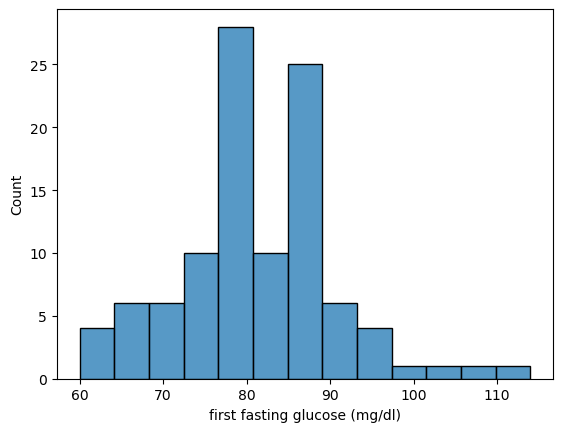

In [212]:
sns.histplot(diabetes["first fasting glucose (mg/dl)"])

* Discrete numerical data range 60-114
* 30 missing entries

* Possible solutions:
* * Mode imputation
    * Glucose numbers highly variable and across fairly large range, mode not reliable enough to assign 30 missing data points to it
  * Median imputation
    * Resistant to outliers, preserves central tendency, creates central bias to distribution
  * Mean imputation
    * Glucose measure essentially continuous so mean suitable, vulnerable to outliers (not present here)
  * Deterministic ratio imputation
    * Data is spread across large range, ratio imputation forces 30 participants to take on measurements based on rounding

In [254]:
# Median
diabetes_gluc_median = diabetes_clean.copy()
diabetes_gluc_median["first fasting glucose (mg/dl)"] = diabetes_gluc_median["first fasting glucose (mg/dl)"].fillna(
    diabetes_gluc_median["first fasting glucose (mg/dl)"].median()
)
print("Missing glucose data", diabetes_gluc_median["first fasting glucose (mg/dl)"].isnull().sum())

# Mode
diabetes_gluc_mode = diabetes_clean.copy()
diabetes_gluc_mode["first fasting glucose (mg/dl)"] = diabetes_gluc_mode["first fasting glucose (mg/dl)"].fillna(
    diabetes_gluc_mode["first fasting glucose (mg/dl)"].mode()[0]
)
print("Missing glucose data", diabetes_gluc_mode["first fasting glucose (mg/dl)"].isnull().sum())

#Mean 
diabetes_gluc_mean = diabetes_clean.copy()
diabetes_gluc_mean["first fasting glucose (mg/dl)"] = diabetes_gluc_mode["first fasting glucose (mg/dl)"].fillna(
 diabetes_gluc_mean["first fasting glucose (mg/dl)"].mean().round()
)
print("Missing glucose data", diabetes_gluc_mean["first fasting glucose (mg/dl)"].isnull().sum())

Missing glucose data 0
Missing glucose data 0
Missing glucose data 0


In [215]:
# Deterministic ratio imputation logic and logging/debug ------ should really rewrite into a function and call for this and pregnancy number
diabetes_gluc_detrat = diabetes_clean.copy()

ratios = diabetes_gluc_detrat["first fasting glucose (mg/dl)"].value_counts(normalize = True)
missing_index = diabetes_gluc_detrat[diabetes_gluc_detrat["first fasting glucose (mg/dl)"].isnull()].index
num_missing = len(missing_index)
print("Missing n =", num_missing)
display(ratios, missing_index)

allocations = (ratios * num_missing)
allocations_rounded = (ratios * num_missing).round()
allocations_remainder = allocations - allocations_rounded
display(allocations, allocations_rounded, allocations_remainder)

while allocations_rounded.sum() < num_missing:
    target_idx = allocations_remainder.idxmax()
    allocations_rounded[allocations_remainder.idxmax()] += 1
    allocations_remainder[allocations_remainder.idxmax()] -= 1

while allocations_rounded.sum() > num_missing:
    target_idx = allocations_remainder.idxmin()
    allocations_rounded[allocations_remainder.idxmin()] -= 1
    allocations_remainder[allocations_remainder.idxmin()] += 1

display(allocations, allocations_rounded, allocations_remainder)

Missing n = 30


first fasting glucose (mg/dl)
79.0     0.098039
85.0     0.078431
78.0     0.068627
77.0     0.049020
89.0     0.049020
86.0     0.049020
84.0     0.039216
74.0     0.039216
75.0     0.039216
80.0     0.039216
72.0     0.039216
87.0     0.039216
66.0     0.029412
88.0     0.029412
81.0     0.029412
90.0     0.029412
62.0     0.019608
68.0     0.019608
83.0     0.019608
96.0     0.019608
73.0     0.009804
60.0     0.009804
82.0     0.009804
93.0     0.009804
70.4     0.009804
103.0    0.009804
109.0    0.009804
64.0     0.009804
76.0     0.009804
78.4     0.009804
101.0    0.009804
91.0     0.009804
65.0     0.009804
70.0     0.009804
92.0     0.009804
97.0     0.009804
80.3     0.009804
114.0    0.009804
Name: proportion, dtype: float64

Index([  0,   3,   6,  10,  12,  13,  21,  27,  28,  36,  37,  38,  40,  44,
        46,  48,  52,  67,  69,  78,  87,  90,  91,  93, 110, 111, 115, 126,
       131, 132],
      dtype='int64')

first fasting glucose (mg/dl)
79.0     2.941176
85.0     2.352941
78.0     2.058824
77.0     1.470588
89.0     1.470588
86.0     1.470588
84.0     1.176471
74.0     1.176471
75.0     1.176471
80.0     1.176471
72.0     1.176471
87.0     1.176471
66.0     0.882353
88.0     0.882353
81.0     0.882353
90.0     0.882353
62.0     0.588235
68.0     0.588235
83.0     0.588235
96.0     0.588235
73.0     0.294118
60.0     0.294118
82.0     0.294118
93.0     0.294118
70.4     0.294118
103.0    0.294118
109.0    0.294118
64.0     0.294118
76.0     0.294118
78.4     0.294118
101.0    0.294118
91.0     0.294118
65.0     0.294118
70.0     0.294118
92.0     0.294118
97.0     0.294118
80.3     0.294118
114.0    0.294118
Name: proportion, dtype: float64

first fasting glucose (mg/dl)
79.0     3.0
85.0     2.0
78.0     2.0
77.0     1.0
89.0     1.0
86.0     1.0
84.0     1.0
74.0     1.0
75.0     1.0
80.0     1.0
72.0     1.0
87.0     1.0
66.0     1.0
88.0     1.0
81.0     1.0
90.0     1.0
62.0     1.0
68.0     1.0
83.0     1.0
96.0     1.0
73.0     0.0
60.0     0.0
82.0     0.0
93.0     0.0
70.4     0.0
103.0    0.0
109.0    0.0
64.0     0.0
76.0     0.0
78.4     0.0
101.0    0.0
91.0     0.0
65.0     0.0
70.0     0.0
92.0     0.0
97.0     0.0
80.3     0.0
114.0    0.0
Name: proportion, dtype: float64

first fasting glucose (mg/dl)
79.0    -0.058824
85.0     0.352941
78.0     0.058824
77.0     0.470588
89.0     0.470588
86.0     0.470588
84.0     0.176471
74.0     0.176471
75.0     0.176471
80.0     0.176471
72.0     0.176471
87.0     0.176471
66.0    -0.117647
88.0    -0.117647
81.0    -0.117647
90.0    -0.117647
62.0    -0.411765
68.0    -0.411765
83.0    -0.411765
96.0    -0.411765
73.0     0.294118
60.0     0.294118
82.0     0.294118
93.0     0.294118
70.4     0.294118
103.0    0.294118
109.0    0.294118
64.0     0.294118
76.0     0.294118
78.4     0.294118
101.0    0.294118
91.0     0.294118
65.0     0.294118
70.0     0.294118
92.0     0.294118
97.0     0.294118
80.3     0.294118
114.0    0.294118
Name: proportion, dtype: float64

first fasting glucose (mg/dl)
79.0     2.941176
85.0     2.352941
78.0     2.058824
77.0     1.470588
89.0     1.470588
86.0     1.470588
84.0     1.176471
74.0     1.176471
75.0     1.176471
80.0     1.176471
72.0     1.176471
87.0     1.176471
66.0     0.882353
88.0     0.882353
81.0     0.882353
90.0     0.882353
62.0     0.588235
68.0     0.588235
83.0     0.588235
96.0     0.588235
73.0     0.294118
60.0     0.294118
82.0     0.294118
93.0     0.294118
70.4     0.294118
103.0    0.294118
109.0    0.294118
64.0     0.294118
76.0     0.294118
78.4     0.294118
101.0    0.294118
91.0     0.294118
65.0     0.294118
70.0     0.294118
92.0     0.294118
97.0     0.294118
80.3     0.294118
114.0    0.294118
Name: proportion, dtype: float64

first fasting glucose (mg/dl)
79.0     3.0
85.0     3.0
78.0     2.0
77.0     2.0
89.0     2.0
86.0     2.0
84.0     1.0
74.0     1.0
75.0     1.0
80.0     1.0
72.0     1.0
87.0     1.0
66.0     1.0
88.0     1.0
81.0     1.0
90.0     1.0
62.0     1.0
68.0     1.0
83.0     1.0
96.0     1.0
73.0     1.0
60.0     1.0
82.0     0.0
93.0     0.0
70.4     0.0
103.0    0.0
109.0    0.0
64.0     0.0
76.0     0.0
78.4     0.0
101.0    0.0
91.0     0.0
65.0     0.0
70.0     0.0
92.0     0.0
97.0     0.0
80.3     0.0
114.0    0.0
Name: proportion, dtype: float64

first fasting glucose (mg/dl)
79.0    -0.058824
85.0    -0.647059
78.0     0.058824
77.0    -0.529412
89.0    -0.529412
86.0    -0.529412
84.0     0.176471
74.0     0.176471
75.0     0.176471
80.0     0.176471
72.0     0.176471
87.0     0.176471
66.0    -0.117647
88.0    -0.117647
81.0    -0.117647
90.0    -0.117647
62.0    -0.411765
68.0    -0.411765
83.0    -0.411765
96.0    -0.411765
73.0    -0.705882
60.0    -0.705882
82.0     0.294118
93.0     0.294118
70.4     0.294118
103.0    0.294118
109.0    0.294118
64.0     0.294118
76.0     0.294118
78.4     0.294118
101.0    0.294118
91.0     0.294118
65.0     0.294118
70.0     0.294118
92.0     0.294118
97.0     0.294118
80.3     0.294118
114.0    0.294118
Name: proportion, dtype: float64

In [216]:
# Performing deterministic ratio imputation using missing entry index and final allocations from previous cell
# lots of allocations with same number, 73.0 and 60.0 assigned an entry just because they're top of the list of 0.294118 numbers
list(allocations_rounded.items())[1]
gluc_detrat_imp_values = []
for i in list(allocations_rounded.items()):
    gluc_detrat_imp_values.extend([i[0]] * int(i[1]))
print(gluc_detrat_imp_values)
diabetes_gluc_detrat.loc[missing_index, "first fasting glucose (mg/dl)"] = gluc_detrat_imp_values
display(diabetes_gluc_detrat.loc[missing_index],
        ("Missing glucose data", diabetes_gluc_detrat["first fasting glucose (mg/dl)"].isnull().sum()))

[79.0, 79.0, 79.0, 85.0, 85.0, 85.0, 78.0, 78.0, 77.0, 77.0, 89.0, 89.0, 86.0, 86.0, 84.0, 74.0, 75.0, 80.0, 72.0, 87.0, 66.0, 88.0, 81.0, 90.0, 62.0, 68.0, 83.0, 96.0, 73.0, 60.0]


,number,age (years),ethnicity,diabetes mellitus,mean diastolic bp (mmhg),mean systolic bp (mmhg),central armellini fat (mm),current gestational age,pregnancies (number),first fasting glucose (mg/dl),bmi pregestational (kg/m),gestational age at birth,type of delivery,child birth weight (g),gestational dm
0,1,20,0.0,0,73.5,125.0,28.10,"12,1",1.0,79.0,33.20,"41,0",1,3840,0
3,9,25,0.0,0,92.5,167.0,39.60,"16,2",4.0,79.0,55.36,"39,4",0,3400,0
6,18,18,0.0,0,72.0,132.0,39.90,"13,1",1.0,79.0,37.18,"39,4",0,3615,0
10,28,25,0.0,0,64.0,115.5,39.90,"16,5",1.0,85.0,26.53,"36,3",0,2625,0
12,34,25,1.0,0,62.5,97.5,30.40,"18,0",2.0,85.0,19.43,"39,2",0,3275,0
13,36,22,0.0,0,69.5,114.5,34.40,"16,4",1.0,85.0,24.69,"40,0",0,3410,0
21,46,32,0.0,0,82.5,124.0,51.20,"18,1",3.0,78.0,28.44,"38,0",0,3705,1
27,64,30,1.0,0,76.0,120.5,53.20,"8,6",3.0,78.0,29.15,"37,3",0,3108,0
28,69,17,1.0,0,61.0,101.5,38.10,"17,0",1.0,77.0,22.15,"38,2",1,3235,0
36,96,19,0.0,0,89.0,139.5,23.40,"15,2",1.0,77.0,23.92,"37,5",0,2585,0


('Missing glucose data', 0)

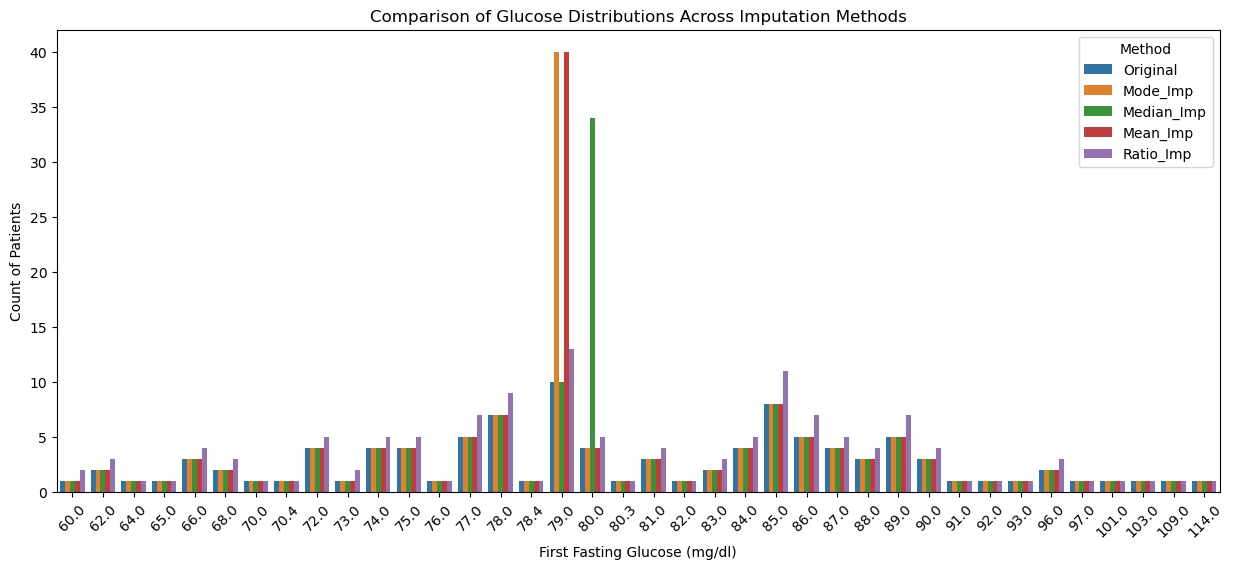

In [258]:
## Comparing data following different imputation methods
# Combine the column from each dataset into a temporary DataFrame for plotting
comparison_df = pd.DataFrame({
    'Original': diabetes_clean["first fasting glucose (mg/dl)"],
    'Mode_Imp': diabetes_gluc_mode["first fasting glucose (mg/dl)"],
    'Median_Imp': diabetes_gluc_median["first fasting glucose (mg/dl)"],
    'Mean_Imp': diabetes_gluc_mean["first fasting glucose (mg/dl)"],
    'Ratio_Imp': diabetes_gluc_detrat["first fasting glucose (mg/dl)"]
})

# Melt the dataframe to make it compatible with seaborn
df_melted = comparison_df.melt(var_name='Method', value_name='Glucose')

plt.figure(figsize=(15, 6))
sns.countplot(data=df_melted, x='Glucose', hue='Method')
plt.title('Comparison of Glucose Distributions Across Imputation Methods')
plt.ylabel('Count of Patients')
plt.xlabel('First Fasting Glucose (mg/dl)')
plt.xticks(rotation=45)
plt.show()

In [256]:
# Descriptive statistics comparison
stats_comparison = pd.DataFrame({
    'Original': [diabetes_clean["first fasting glucose (mg/dl)"].mean(), diabetes_clean["first fasting glucose (mg/dl)"].median(), diabetes_clean["first fasting glucose (mg/dl)"].std(), diabetes_clean["first fasting glucose (mg/dl)"].var()],
    'Mode imputation': [diabetes_gluc_mode["first fasting glucose (mg/dl)"].mean(), diabetes_gluc_mode["first fasting glucose (mg/dl)"].median(), diabetes_gluc_mode["first fasting glucose (mg/dl)"].std(), diabetes_gluc_mode["first fasting glucose (mg/dl)"].var()],
    'Median imputation': [diabetes_gluc_median["first fasting glucose (mg/dl)"].mean(), diabetes_gluc_median["first fasting glucose (mg/dl)"].median(), diabetes_gluc_median["first fasting glucose (mg/dl)"].std(), diabetes_gluc_median["first fasting glucose (mg/dl)"].var()],
    'Mean imputation': [diabetes_gluc_mean["first fasting glucose (mg/dl)"].mean(), diabetes_gluc_mean["first fasting glucose (mg/dl)"].median(), diabetes_gluc_mean["first fasting glucose (mg/dl)"].std(), diabetes_gluc_mean["first fasting glucose (mg/dl)"].var()],
    'Ratio imputation': [diabetes_gluc_detrat["first fasting glucose (mg/dl)"].mean(), diabetes_gluc_detrat["first fasting glucose (mg/dl)"].median(), diabetes_gluc_detrat["first fasting glucose (mg/dl)"].std(), diabetes_gluc_detrat["first fasting glucose (mg/dl)"].var()]
}, index=['Mean', 'Median', 'Std Dev', 'Variance'])

print(stats_comparison)

           Original  Mode imputation  Median imputation  Mean imputation  \
Mean      81.138235        80.652273          80.879545        80.652273   
Median    80.000000        79.000000          80.000000        79.000000   
Std Dev    9.376430         8.282074           8.246996         8.282074   
Variance  87.917434        68.592743          68.012937        68.592743   

          Ratio imputation  
Mean             80.811364  
Median           80.000000  
Std Dev           9.161783  
Variance         83.938267  


In [260]:
# Correlation with other feature comparison following imputation
# List your 4 datasets (Original plus your 3 imputed versions)
datasets = {
    'Original': diabetes_clean,
    'Median_Imp': diabetes_gluc_median,
    'Mean_Imp': diabetes_gluc_mean,
    'Mode_Imp': diabetes_gluc_mode,
    'Ratio_Imp': diabetes_gluc_detrat
}

# Create an empty list to store our correlation results
corr_summary = []

for name, df in datasets.items():
    # Calculate correlations for this specific dataset
    corr_age = df["first fasting glucose (mg/dl)"].corr(df['age (years)'])
    corr_bmi = df["first fasting glucose (mg/dl)"].corr(df['bmi pregestational (kg/m)'])
    
    corr_summary.append({
        'Dataset/Method': name,
        'Glucose vs Age Corr': corr_age,
        'Glucose vs BMI Corr': corr_bmi
    })

# Turn the results into a clean, presentable DataFrame
corr_comparison_df = pd.DataFrame(corr_summary)
print(corr_comparison_df.to_string(index=False))

Dataset/Method  Glucose vs Age Corr  Glucose vs BMI Corr
      Original             0.193860             0.331966
    Median_Imp             0.179823             0.263253
      Mean_Imp             0.182525             0.254808
      Mode_Imp             0.182525             0.254808
     Ratio_Imp             0.135190             0.176908


**Looking at feature: bmi pregestational (kg/m)**

<Axes: xlabel='bmi pregestational (kg/m)', ylabel='Count'>

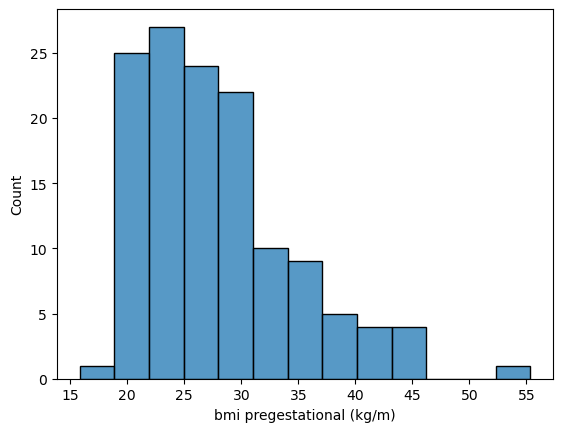

In [284]:
sns.histplot(diabetes["bmi pregestational (kg/m)"])

* Continuous numerical data
* 1 null value
* Solution: use mean

In [276]:
diabetes_clean["bmi pregestational (kg/m)"] = diabetes_clean["bmi pregestational (kg/m)"].fillna(
    diabetes_clean["bmi pregestational (kg/m)"].mean()
)
print("Missing bmi pregestational data =", diabetes_clean["bmi pregestational (kg/m)"].isnull().sum())

Missing bmi pregestational data = 0


**Iterative KNN imputation for all missing data features**

**Comparing all imputation strategies**

**Final assignment of missing data based on favoured imputation strategy**